In [1]:
import pandas as pd
import requests
import pandas as pd
import requests

In [3]:
# ====================================================================
# 1. EXTRAÇÃO DOS CÓDIGOS IBGE VIA API (O "De/Para")
# ====================================================================
print("Buscando dados na API do IBGE...")
url_ibge = "https://servicodados.ibge.gov.br/api/v1/localidades/municipios"
response = requests.get(url_ibge)
dados_json = response.json()

# Dicionário Oficial do IBGE: Os 2 primeiros dígitos representam o Estado
dict_ufs = {
    '11': 'RO', '12': 'AC', '13': 'AM', '14': 'RR', '15': 'PA', '16': 'AP', '17': 'TO',
    '21': 'MA', '22': 'PI', '23': 'CE', '24': 'RN', '25': 'PB', '26': 'PE', '27': 'AL', '28': 'SE', '29': 'BA',
    '31': 'MG', '32': 'ES', '33': 'RJ', '35': 'SP',
    '41': 'PR', '42': 'SC', '43': 'RS',
    '50': 'MS', '51': 'MT', '52': 'GO', '53': 'DF'
}

lista_municipios = []
for mun in dados_json:
    id_mun = str(mun['id'])
    lista_municipios.append({
        'id_municipio': id_mun,
        'nome_municipio': mun['nome'],
        'uf': dict_ufs.get(id_mun[:2], 'NA') # Busca a UF diretamente pelos 2 primeiros dígitos
    })

df_ibge = pd.DataFrame(lista_municipios)
print(f"Total de municípios IBGE: {df_ibge.shape[0]}")
display(df_ibge.head(3))


# ====================================================================
# 2. LIMPEZA E CRUZAMENTO DOS DADOS DO ATLAS (VULNERABILIDADE)
# ====================================================================
print("\nProcessando base do Atlas Brasil...")
# Carregue o seu arquivo csv (substitua o nome e o separador conforme necessário)
df_atlas = pd.read_excel("vulnerabilidade.xlsx") 

# Extraindo a cidade e o estado da coluna "Territorialidades" (Ex: "Adamantina (SP)")
# Usamos regex para pegar o nome e a UF entre parênteses
df_atlas[['nome_municipio', 'uf']] = df_atlas['Territorialidades'].str.extract(r'^(.*?)\s*\((.*?)\)$')

# Padronizando para letras minúsculas para evitar erros no merge
df_atlas['nome_municipio'] = df_atlas['nome_municipio'].str.lower().str.strip()
df_ibge['nome_municipio'] = df_ibge['nome_municipio'].str.lower().str.strip()

# Fazendo o Join para trazer o id_municipio para a base do Atlas
df_atlas_codificado = pd.merge(df_atlas, df_ibge, on=['nome_municipio', 'uf'], how='inner')

# Selecionando apenas as colunas de 2010 (as gerais, sem desagregação) e o id_municipio
colunas_interesse = [
    'id_municipio',
    '% de 15 a 24 anos de idade que não estudam nem trabalham em domicílios vulneráveis à pobreza 2010',
    '% de pessoas em domicílios vulneráveis à pobreza e em que ninguém tem ensino fundamental completo 2010'
]
df_atlas_final = df_atlas_codificado[colunas_interesse]
display(df_atlas_final.head(3))


# ====================================================================
# 3. AGREGAÇÃO DOS DADOS DO CENSO ESCOLAR 2025
# ====================================================================
print("\nProcessando base do Censo Escolar...")
# Dica: O Censo Escolar é muito pesado. Apenas as colunas que importam para o modelo.
colunas_censo = [
    'CO_MUNICIPIO', 'CO_REDE', 
    'IN_AGUA_POTAVEL', 'IN_ESGOTO_REDE_PUBLICA', 'IN_INTERNET', 
    'IN_BIBLIOTECA_SALA_LEITURA', 'IN_COMPUTADOR'
]

# Ajuste o nome do arquivo, separador (| ou ;) e encoding conforme o arquivo do INEP
df_censo = pd.read_csv("censo_escolar_2025.csv", usecols=colunas_censo, sep=";", encoding="latin1")

# Agregando por Município e Rede de Ensino (tirando a média)
# Isso transforma "Escola X e Y" em "% de escolas da rede municipal com internet", por exemplo
df_censo_agg = df_censo.groupby(['CO_MUNICIPIO', 'CO_REDE']).mean().reset_index()

# Renomeando a coluna para bater com a nossa camada Gold
df_censo_agg.rename(columns={'CO_MUNICIPIO': 'id_municipio', 'CO_REDE': 'rede'}, inplace=True)
# Garantindo que seja string para o merge futuro
df_censo_agg['id_municipio'] = df_censo_agg['id_municipio'].astype(str)

display(df_censo_agg.head(3))

# ====================================================================
# 4. SALVANDO OS DADOS TRATADOS
# ====================================================================
# Exportamos os dataframes limpos para a pasta /data/preprocessing/
df_atlas_final.to_parquet("atlas_vulnerabilidade_limpo.parquet")
df_censo_agg.to_parquet("censo_escolar_agregado.parquet")
print("\nBases limpas e exportadas com sucesso!")

Buscando dados na API do IBGE...
Total de municípios IBGE: 5571


,id_municipio,nome_municipio,uf
0,1100015,Alta Floresta D'Oeste,RO
1,1100023,Ariquemes,RO
2,1100031,Cabixi,RO



Processando base do Atlas Brasil...


,id_municipio,% de 15 a 24 anos de idade que não estudam nem trabalham em domicílios vulneráveis à pobreza 2010,% de pessoas em domicílios vulneráveis à pobreza e em que ninguém tem ensino fundamental completo 2010
0,3500105,3.10,3.64
1,3500204,5.60,4.38
2,3500303,7.74,10.32



Processando base do Censo Escolar...


,id_municipio,rede,IN_AGUA_POTAVEL,IN_ESGOTO_REDE_PUBLICA,IN_BIBLIOTECA_SALA_LEITURA,IN_COMPUTADOR,IN_INTERNET
0,1100015,1,0.84,0.0,0.560000,0.88,0.92
1,1100015,2,1.00,0.0,0.000000,1.00,1.00
2,1100023,1,1.00,0.0,0.769231,1.00,1.00



Bases limpas e exportadas com sucesso!



--- Profiling: Base do Atlas (Vulnerabilidade) ---


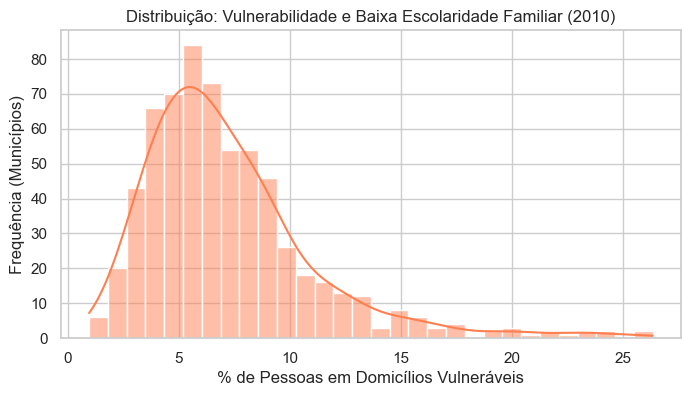


--- Profiling: Base do Censo Escolar Agregado ---


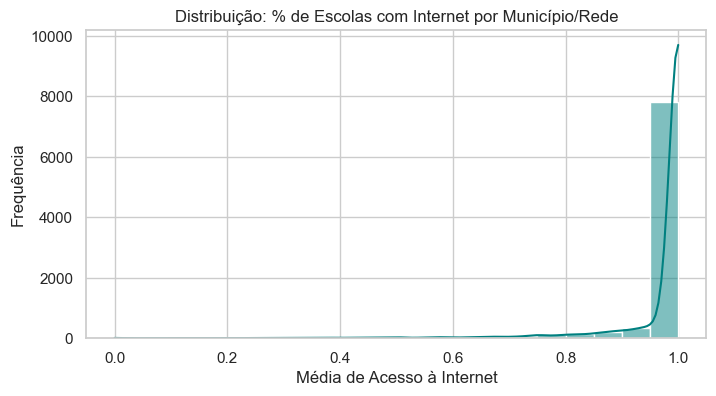


Valores Nulos na Base do Atlas:


id_municipio                                                                                              0
% de 15 a 24 anos de idade que não estudam nem trabalham em domicílios vulneráveis à pobreza 2010         1
% de pessoas em domicílios vulneráveis à pobreza e em que ninguém tem ensino fundamental completo 2010    0
dtype: int64


Valores Nulos na Base do Censo Escolar:


id_municipio                    0
rede                            0
IN_AGUA_POTAVEL               312
IN_ESGOTO_REDE_PUBLICA        312
IN_BIBLIOTECA_SALA_LEITURA    312
IN_COMPUTADOR                 312
IN_INTERNET                   312
dtype: int64

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ====================================================================
# 3.5 VISUALIZAÇÃO TÉCNICA (DATA PROFILING) ANTES DE EXPORTAR
# ====================================================================
print("\n--- Profiling: Base do Atlas (Vulnerabilidade) ---")
# Verificando a distribuição da vulnerabilidade nos municípios
plt.figure(figsize=(8, 4))
sns.histplot(df_atlas_final['% de pessoas em domicílios vulneráveis à pobreza e em que ninguém tem ensino fundamental completo 2010'], 
             bins=30, kde=True, color='coral')
plt.title("Distribuição: Vulnerabilidade e Baixa Escolaridade Familiar (2010)")
plt.xlabel("% de Pessoas em Domicílios Vulneráveis")
plt.ylabel("Frequência (Municípios)")
plt.show()


print("\n--- Profiling: Base do Censo Escolar Agregado ---")
# Verificando como ficou a média de acesso à internet por município
plt.figure(figsize=(8, 4))
sns.histplot(df_censo_agg['IN_INTERNET'], bins=20, kde=True, color='teal')
plt.title("Distribuição: % de Escolas com Internet por Município/Rede")
plt.xlabel("Média de Acesso à Internet")
plt.ylabel("Frequência")
plt.show()

# Resumo de valores nulos após os cruzamentos
print("\nValores Nulos na Base do Atlas:")
display(df_atlas_final.isnull().sum())

print("\nValores Nulos na Base do Censo Escolar:")
display(df_censo_agg.isnull().sum())